In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import PowerTransformer

In [132]:
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2021.csv")

In [133]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum()/len(df)*100).round(2)
})


missing = missing[missing["Missing Values"] > 0]

print(missing.sort_values(by="Missing Values", ascending=False))

Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


In [134]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 12828


In [135]:
df_cleaned = df.drop_duplicates(keep='first')

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")

Original shape: (236378, 22)
Cleaned shape: (223550, 22)


In [136]:
df = df.drop_duplicates()

In [137]:
print(df["Diabetes_012"].value_counts())

Diabetes_012
0.0    184542
2.0     33395
1.0      5613
Name: count, dtype: int64


In [138]:
df["Diabetes_012"] = df["Diabetes_012"].replace({
    1:1,
    2:1
})

print(df["Diabetes_012"].value_counts())

Diabetes_012
0.0    184542
1.0     39008
Name: count, dtype: int64


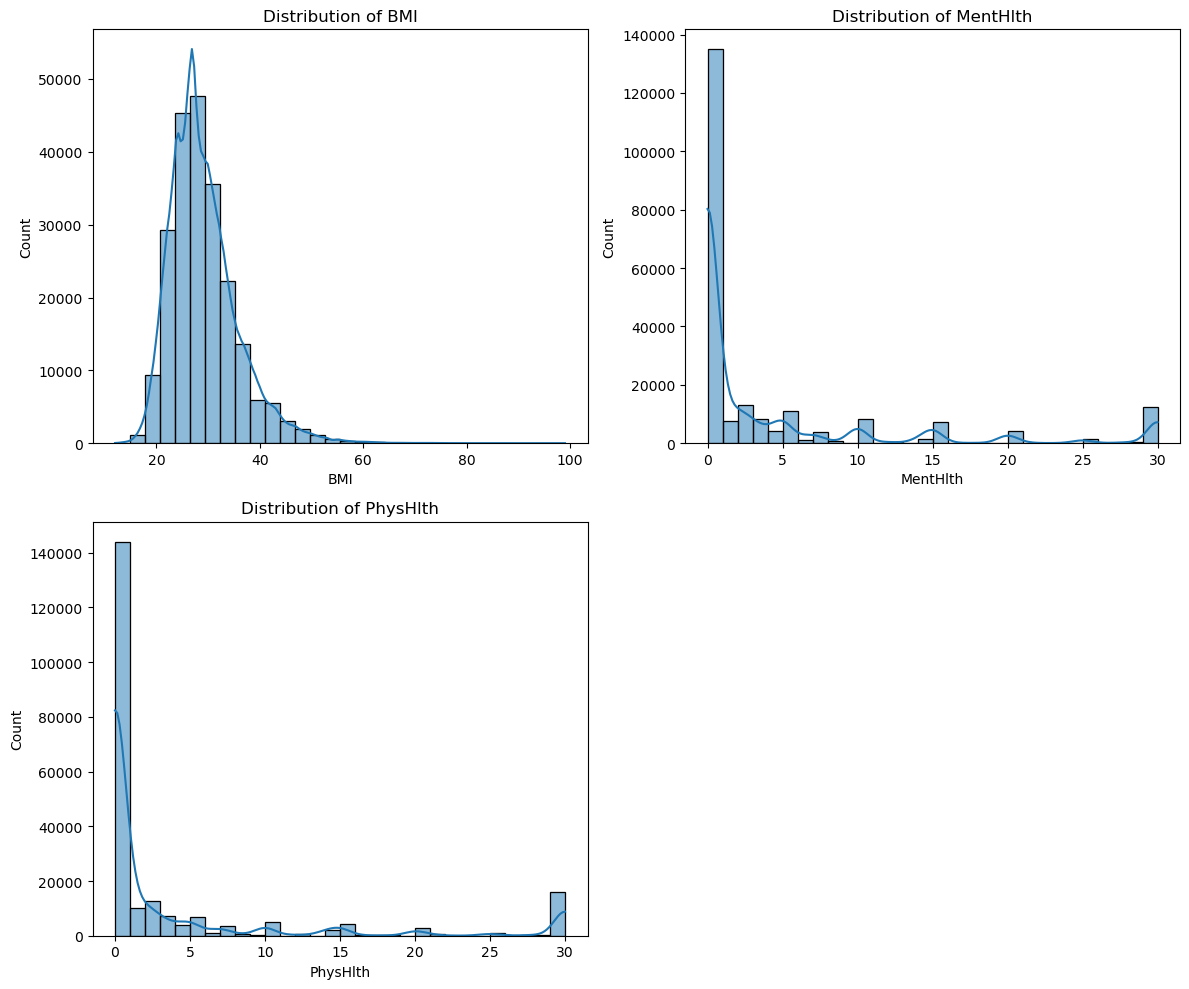

In [139]:
continuous_features = [
    "BMI",
    "MentHlth",
    "PhysHlth"
]

plt.figure(figsize=(12,10))

for i, col in enumerate(continuous_features, 1):
    plt.subplot(2,2,i)
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [141]:
continuous_cols = ["BMI", "MentHlth", "PhysHlth"]

outlier_summary = []

for col in continuous_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = max(0, Q1 - 1.5 * IQR)
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Outliers": outliers,
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2)
    })

    df[col] = df[col].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

df.to_csv("outliers_treated.csv", index=False)

print(df.shape)


    Feature  Outliers  Lower Bound  Upper Bound
0       BMI         0         14.5         42.5
1  MentHlth         0          0.0         10.0
2  PhysHlth         0          0.0          7.5
(223550, 22)


In [142]:
df = pd.read_csv("outliers_treated.csv")
continuous_features = [
    "BMI",
    "MentHlth",
    "PhysHlth"
]
skewness = df[continuous_features].skew()
print(skewness)

BMI         0.545797
MentHlth    1.234656
PhysHlth    1.287356
dtype: float64


In [143]:
continuous_cols = ["MentHlth", "PhysHlth"]

pt = PowerTransformer(method="yeo-johnson")

df[continuous_cols] = pt.fit_transform(df[continuous_cols])
print(df[continuous_cols].skew())

df.to_csv("skewness_treated.csv", index=False)

MentHlth    0.550488
PhysHlth    0.691878
dtype: float64


In [144]:
df = pd.read_csv("skewness_treated.csv")
df.drop(
    columns=[
        "NoDocbcCost",
        "Education",
        "Income", 
    ],
    inplace=True
)

X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

rus = RandomUnderSampler(random_state=42)

X_balanced, y_balanced = rus.fit_resample(X, y)

balanced_df = pd.concat(
    [
        pd.DataFrame(X_balanced, columns=X.columns),
        pd.Series(y_balanced, name="Diabetes_012")
    ],
    axis=1
)

print("Balanced dataset")
print(balanced_df["Diabetes_012"].value_counts())

print(df.shape)

Balanced dataset
Diabetes_012
0.0    39008
1.0    39008
Name: count, dtype: int64
(223550, 19)


In [145]:
balanced_df.to_csv("balanced_dataset.csv", index=False)